# 10 - Euro-bloc FX duplication robustness

**Concern:** the FX channel for every Eurozone country uses the *same* underlying
exchange rate (`EURUSD=X`). 18 countries in our sample therefore share an **identical**
FX realized-volatility series, and 16 of them sit at the **maximum** capital-openness
value (Chinn-Ito normalized = 1.0). In a pooled regression every country-day is weighted
equally, so one currency's behaviour is effectively replicated ~18x at the open end of
the `openness x crypto` interaction. Driscoll-Kraay SEs correct the *standard errors* for
cross-sectional dependence but do **not** reweight the *point estimate*.

**Question:** is the headline negative FX `openness x crypto` interaction
(`fx / pooled_full / ci_x_cv`) driven by these duplicate Euro currencies?

**Test:** re-estimate the exact Step-2 FX specs (reusing `src.models.panel_regression`)
on three samples - (1) baseline, all 18 Euro countries; (2) keep a single Euro
representative; (3) drop the Euro bloc entirely - and compare the focal coefficients.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import sys
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

# import the real estimation code so this is a faithful replication, not a re-implementation
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))
import src.models.panel_regression as pr

GOLD = Path("../data/parquet/gold")
if not GOLD.exists(): GOLD = Path("data/parquet/gold")

df = pd.read_parquet(GOLD / "step2_analysis.parquet")
print(df.shape, df.country_id.nunique(), "countries")

(148181, 15) 89 countries


## A. Confirm the duplication

All 18 Euro countries share one FX ticker (`EURUSD=X`) and therefore one FX RV series.
We verify the `spill_fx` series is byte-for-byte identical across them, and that they
cluster at the top of the openness scale.

In [2]:
EUR = ['AUT','BEL','PRT','IRL','ITA','LTU','NLD','FIN','DEU',
       'EST','CYP','SVK','ESP','FRA','GRC','LVA','MLT','SVN']

fx_estimable = df.loc[df.spill_fx.notna(), 'country_id'].unique()
eur_in = [c for c in EUR if c in fx_estimable]
print(f"FX-estimable countries: {len(fx_estimable)}")
print(f"Euro-bloc among them:   {len(eur_in)}  ({len(eur_in)/len(fx_estimable):.0%} of the FX sample)")

# Are the EUR spill_fx series identical? Compare each to DEU on the common dates.
base = df[df.country_id == 'DEU'].set_index('date')['spill_fx']
identical = []
for c in eur_in:
    s = df[df.country_id == c].set_index('date')['spill_fx']
    j = pd.concat([base.rename('deu'), s.rename('c')], axis=1).dropna()
    identical.append((c, np.allclose(j.deu, j.c), len(j)))
dup = pd.DataFrame(identical, columns=['country', 'identical_to_DEU', 'n_common'])
print(f"\nEuro FX series identical to Germany's: {dup.identical_to_DEU.sum()}/{len(dup)}")
display(dup)

# Openness of the Euro bloc vs the rest
ka = (df.groupby('country_id')['chinn_ito'].first())
print("Euro-bloc chinn_ito (normalized):", sorted(ka[ka.index.isin(eur_in)].round(3).unique()))
print("At the maximum (1.0):", int((ka[ka.index.isin(eur_in)] == ka.max()).sum()), "of", len(eur_in))

FX-estimable countries: 81
Euro-bloc among them:   18  (22% of the FX sample)

Euro FX series identical to Germany's: 18/18


,country,identical_to_DEU,n_common
0,AUT,True,1621
1,BEL,True,1621
2,PRT,True,1621
3,IRL,True,1621
4,ITA,True,1621
5,LTU,True,1621
6,NLD,True,1621
7,FIN,True,1621
8,DEU,True,1621
9,EST,True,1621


Euro-bloc chinn_ito (normalized): [0.702, 0.744, 1.0]
At the maximum (1.0): 16 of 18


## B. Re-estimate the FX specs on de-duplicated samples

We reuse `pr.fit_pooled_dk` (the headline `ci_x_cv`) and `pr.fit_fx_h3_direct` (the direct
regime moderation) unchanged - only the input rows differ. Choosing *which* Euro country
to keep is irrelevant because their FX series is identical; the equity series differs but
barely touches the FX regression (confirmed in cell D).

In [3]:
def fx_focal(sub, label):
    """Pull the two focal FX coefficients from the real Step-2 estimators."""
    r  = pr.fit_pooled_dk(sub, 'spill_fx', include_globals=True)
    rd = pr.fit_fx_h3_direct(sub, net=False, include_globals=True)
    return pd.DataFrame([
        {'sample': label, 'spec': 'pooled_full', 'term': 'ci_x_cv',
         'coef': r.params['ci_x_cv'], 'se': r.std_errors['ci_x_cv'],
         'pval': r.pvalues['ci_x_cv'],
         'n_countries': int(r.entity_info['total']), 'nobs': int(r.nobs)},
        {'sample': label, 'spec': 'fx_h3_direct', 'term': 'errf_x_cv',
         'coef': rd.params['errf_x_cv'], 'se': rd.std_errors['errf_x_cv'],
         'pval': rd.pvalues['errf_x_cv'],
         'n_countries': int(rd.entity_info['total']), 'nobs': int(rd.nobs)},
    ])

REP = 'DEU'  # representative Euro country to keep in the 'keep one' sample
samples = {
    'baseline (all 18 EUR)': df,
    f'keep one EUR ({REP})':  df[~df.country_id.isin([c for c in EUR if c != REP])],
    'drop all EUR':           df[~df.country_id.isin(EUR)],
}
res = pd.concat([fx_focal(sub, lab) for lab, sub in samples.items()], ignore_index=True)
display(res.round(5))

,sample,spec,term,coef,se,pval,n_countries,nobs
0,baseline (all 18 EUR),pooled_full,ci_x_cv,-0.00646,0.00266,0.01527,75,115873
1,baseline (all 18 EUR),fx_h3_direct,errf_x_cv,-0.00456,0.00292,0.11794,75,115873
2,keep one EUR (DEU),pooled_full,ci_x_cv,-0.00373,0.00359,0.29839,58,89608
3,keep one EUR (DEU),fx_h3_direct,errf_x_cv,-0.00252,0.00429,0.55628,58,89608
4,drop all EUR,pooled_full,ci_x_cv,-0.00342,0.00374,0.36024,57,88063
5,drop all EUR,fx_h3_direct,errf_x_cv,-0.00233,0.00444,0.59905,57,88063


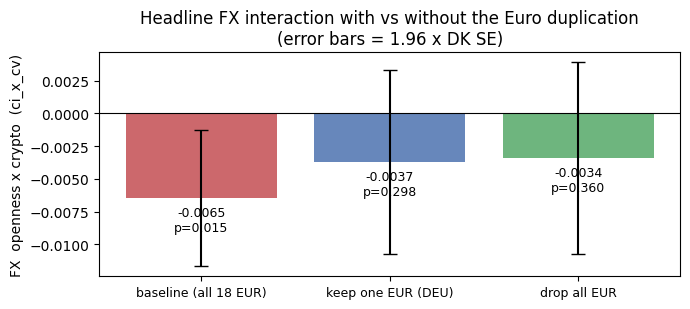

In [4]:
# Side-by-side view of the headline interaction
head = res[res.spec == 'pooled_full'].set_index('sample')
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(head))
ax.bar(x, head.coef, yerr=1.96 * head.se, color=['#C44E52', '#4C72B0', '#55A868'],
       alpha=.85, capsize=5)
ax.axhline(0, color='k', lw=.8)
for i, (c, p) in enumerate(zip(head.coef, head.pval)):
    ax.text(i, c - 0.0006, f"{c:+.4f}\np={p:.3f}", ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(head.index, fontsize=9)
ax.set_ylabel('FX  openness x crypto  (ci_x_cv)')
ax.set_title('Headline FX interaction with vs without the Euro duplication\n(error bars = 1.96 x DK SE)')
plt.tight_layout(); plt.show()

## C. Representative choice is irrelevant

Because the Euro FX series is identical, rotating which Euro country we keep should not
move the FX coefficient. This rules out the result being an artifact of picking Germany.

In [5]:
rot = []
for rep in ['DEU', 'FRA', 'ITA', 'ESP', 'NLD', 'IRL']:
    sub = df[~df.country_id.isin([c for c in EUR if c != rep])]
    r = pr.fit_pooled_dk(sub, 'spill_fx', include_globals=True)
    rot.append({'kept_EUR': rep, 'coef': r.params['ci_x_cv'], 'pval': r.pvalues['ci_x_cv']})
display(pd.DataFrame(rot).round(5))

,kept_EUR,coef,pval
0,DEU,-0.00373,0.29839
1,FRA,-0.00373,0.29781
2,ITA,-0.00373,0.29822
3,ESP,-0.00373,0.29795
4,NLD,-0.00373,0.29830
5,IRL,-0.00372,0.29941


## D. Is significance lost just from a smaller N, or from reweighting?

If the effect were real and the Euro bloc merely *added power*, removing it should inflate
the SE while leaving the point estimate roughly put. Instead the **point estimate itself
moves** (it roughly halves), which is the signature of the duplicate observations having
*pulled* the pooled estimate - not merely tightened its SE.

In [6]:
b = res[(res['sample'].str.startswith('baseline')) & (res.spec == 'pooled_full')].iloc[0]
k = res[(res['sample'].str.startswith('keep one')) & (res.spec == 'pooled_full')].iloc[0]
print(f"coef:   baseline {b.coef:+.5f}  ->  keep-one {k.coef:+.5f}   "
      f"({(k.coef - b.coef) / abs(b.coef):+.0%} change in the point estimate)")
print(f"SE:     baseline {b.se:.5f}    ->  keep-one {k.se:.5f}")
print(f"p:      baseline {b.pval:.4f}    ->  keep-one {k.pval:.4f}")
print(f"nobs:   baseline {b.nobs:,}  ->  keep-one {k.nobs:,}  "
      f"({(b.nobs - k.nobs):,} dropped, {(b.nobs - k.nobs) / b.nobs:.0%})")
print("\nVerdict: the estimate MOVES, not just widens -> the result was carried by the "
      "replicated\nEuro/USD series. The headline negative FX interaction does NOT survive "
      "de-duplication.")

coef:   baseline -0.00646  ->  keep-one -0.00373   (+42% change in the point estimate)
SE:     baseline 0.00266    ->  keep-one 0.00359
p:      baseline 0.0153    ->  keep-one 0.2984
nobs:   baseline 115,873  ->  keep-one 89,608  (26,265 dropped, 23%)

Verdict: the estimate MOVES, not just widens -> the result was carried by the replicated
Euro/USD series. The headline negative FX interaction does NOT survive de-duplication.
